# reading data

In [ ]:
import os
import pandas as pd
import numpy as np
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LogNorm


data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"

round_list = ["Round1", "Round2", "Round3"]
mode_list = ["De_novo_Results"]


TASK_LIST_DENOVO = [
    'MolCraft_generated_molecules',
    'DecompDiff_generated_molecules',
    'FLAG_generated_molecules',
    'PocketFlow_generated_molecules',
    'SurfGen_generated_molecules',
    'TargetDiff_generated_molecules',
    # 'TamGen_generated_molecules',
    "Pocket2Mol_generated_molecules",
    "diffSBDD_cond_crossdocked_generated_molecules",
    "diffSBDD_cond_moad_generated_molecules"
]

DENOVO_NAME_MAPPING = {
    "MolCraft_generated_molecules": "MolCraft",
    "DecompDiff_generated_molecules": "DecompDiff",
    "FLAG_generated_molecules": "FLAG",
    "PocketFlow_generated_molecules": "PocketFlow",
    "SurfGen_generated_molecules": "SurfGen",
    "TargetDiff_generated_molecules": "TargetDiff",
    # "TamGen_generated_molecules": "TamGen",
    "Pocket2Mol_generated_molecules": "Pocket2Mol",
    "diffSBDD_cond_crossdocked_generated_molecules": "DiffSBDD-C",
    "diffSBDD_cond_moad_generated_molecules": "DiffSBDD-M",
}


results_all = []
results_seen = []
results_unseen = []

for round_name in round_list:
    for mode in mode_list:
        if mode == "De_novo_Results":
            task_list = TASK_LIST_DENOVO
            name_mapping = DENOVO_NAME_MAPPING
            task_type = "De novo"
        
        for task in task_list:
            yaml_path = os.path.join(data_path, round_name, mode, task, "results.yaml")
            with open(yaml_path, 'r') as f:
                result = yaml.safe_load(f)

                results_all.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    "gen_25": result['metrics']['StrainEnergy']['all']['StrainEnergy25%'],
                    "gen_50": result['metrics']['StrainEnergy']['all']['StrainEnergy50%'],
                    "gen_75": result['metrics']['StrainEnergy']['all']['StrainEnergy75%'],
                    "vina_25": result['metrics']['StrainEnergy_docked']['all']['StrainEnergy25%'],
                    "vina_50": result['metrics']['StrainEnergy_docked']['all']['StrainEnergy50%'],
                    "vina_75": result['metrics']['StrainEnergy_docked']['all']['StrainEnergy75%'],
                })
                
                results_seen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    "gen_25": result['metrics']['StrainEnergy']['seen']['StrainEnergy25%'],
                    "gen_50": result['metrics']['StrainEnergy']['seen']['StrainEnergy50%'],
                    "gen_75": result['metrics']['StrainEnergy']['seen']['StrainEnergy75%'],
                    "vina_25": result['metrics']['StrainEnergy_docked']['seen']['StrainEnergy25%'],
                    "vina_50": result['metrics']['StrainEnergy_docked']['seen']['StrainEnergy50%'],
                    "vina_75": result['metrics']['StrainEnergy_docked']['seen']['StrainEnergy75%'],
                })
                
                results_unseen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    "gen_25": result['metrics']['StrainEnergy']['unseen']['StrainEnergy25%'],
                    "gen_50": result['metrics']['StrainEnergy']['unseen']['StrainEnergy50%'],
                    "gen_75": result['metrics']['StrainEnergy']['unseen']['StrainEnergy75%'],
                    "vina_25": result['metrics']['StrainEnergy_docked']['unseen']['StrainEnergy25%'],
                    "vina_50": result['metrics']['StrainEnergy_docked']['unseen']['StrainEnergy50%'],
                    "vina_75": result['metrics']['StrainEnergy_docked']['unseen']['StrainEnergy75%'],
                })
                

df_results_all = pd.DataFrame(results_all)
df_results_seen = pd.DataFrame(results_seen)
df_results_unseen = pd.DataFrame(results_unseen)


all_key = [
    "gen_25",
    "gen_50",
    "gen_75",
    "vina_25",
    "vina_50",
    "vina_75",
]


df_mean_all = (
    df_results_all
    .groupby(["Model", "Type"], as_index=False)[all_key]
    .mean()
)

df_mean_seen = (
    df_results_seen
    .groupby(["Model", "Type"], as_index=False)[all_key]
    .mean()
)

df_mean_unseen = (
    df_results_unseen
    .groupby(["Model", "Type"], as_index=False)[all_key]
    .mean()
)

def prepare_heatmap_data(df_mean):
    """
    将 df_mean 转换为绘图所需的格式
    """
    # 重命名列以匹配原代码的格式
    result_df = df_mean.rename(columns={
        "Model": "Models",
        "gen_25": "gen_mean_25",
        "gen_50": "gen_mean_50",
        "gen_75": "gen_mean_75",
        "vina_25": "vina_mean_25",
        "vina_50": "vina_mean_50",
        "vina_75": "vina_mean_75",
    })
    
    # 按 gen_mean_75 降序排序
    result_df = result_df.sort_values("gen_mean_75", ascending=False).reset_index(drop=True)
    
    return result_df

# ========== 绘图函数 ==========
def plot_strain_heatmap(result_df, save_file, title_suffix=""):
    """
    绘制 Strain Energy 热力图
    """
    heatmap_data_gen = []
    heatmap_data_vina = []

    for metric in ["25", "50", "75"]:
        for condition in ["gen_mean", "vina_mean"]:
            col_name = f"{condition}_{metric}"
            values = result_df[col_name].tolist()
            if condition == "gen_mean":
                heatmap_data_gen.append(values)
            elif condition == "vina_mean":
                heatmap_data_vina.append(values)

    xticklabels_with_gaps = ["25%", "50%", "75%"]

    def add_gaps(heatmap_data):
        heatmap_data_with_gaps = []
        for i in range(0, len(heatmap_data), 3):
            heatmap_data_with_gaps.append(heatmap_data[i])     # 25
            heatmap_data_with_gaps.append(heatmap_data[i+1])   # 50
            heatmap_data_with_gaps.append(heatmap_data[i+2])   # 75
        return np.array(heatmap_data_with_gaps).T

    heatmap_data_gen_with_gaps = add_gaps(heatmap_data_gen)
    heatmap_data_vina_with_gaps = add_gaps(heatmap_data_vina)

    fig, axes = plt.subplots(1, 2, figsize=(4, 5), dpi=300)

    norm = LogNorm(vmin=15, vmax=15000)

    # gen
    sns.heatmap(
        heatmap_data_gen_with_gaps,
        cmap="coolwarm",
        xticklabels=xticklabels_with_gaps,
        yticklabels=result_df["Models"],
        cbar=False,
        square=True,
        ax=axes[0],
        norm=norm
    )
    axes[0].set_title("Gen")
    axes[0].add_patch(
        patches.Rectangle(
            (0, 0), 3, len(result_df),
            transform=axes[0].transData,
            color="black", fill=False, linewidth=2
        )
    )

    # vina
    sns.heatmap(
        heatmap_data_vina_with_gaps,
        cmap="coolwarm",
        xticklabels=xticklabels_with_gaps,
        yticklabels=[],
        cbar=False,
        square=True,
        ax=axes[1],
        norm=norm
    )
    axes[1].set_title("Vina")
    axes[1].add_patch(
        patches.Rectangle(
            (0, 0), 3, len(result_df),
            transform=axes[1].transData,
            color="black", fill=False, linewidth=2
        )
    )

    cbar = fig.colorbar(axes[0].collections[0], ax=axes, orientation='vertical', fraction=0.03, pad=0.08)
    cbar.set_label("Strain Energy")
    cbar.ax.set_position([1.05, 0.15, 0.02, 0.7])

    for ax in axes:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(left=False, bottom=False)

    for ax in axes:
        plt.sca(ax)
        plt.yticks(fontsize=8)
        plt.xticks(fontsize=8)

    plt.tight_layout()
    plt.savefig(save_file, bbox_inches='tight', format='svg')
    plt.show()
    plt.close()

/tmp/ipykernel_4075676/3061628019.py:238: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


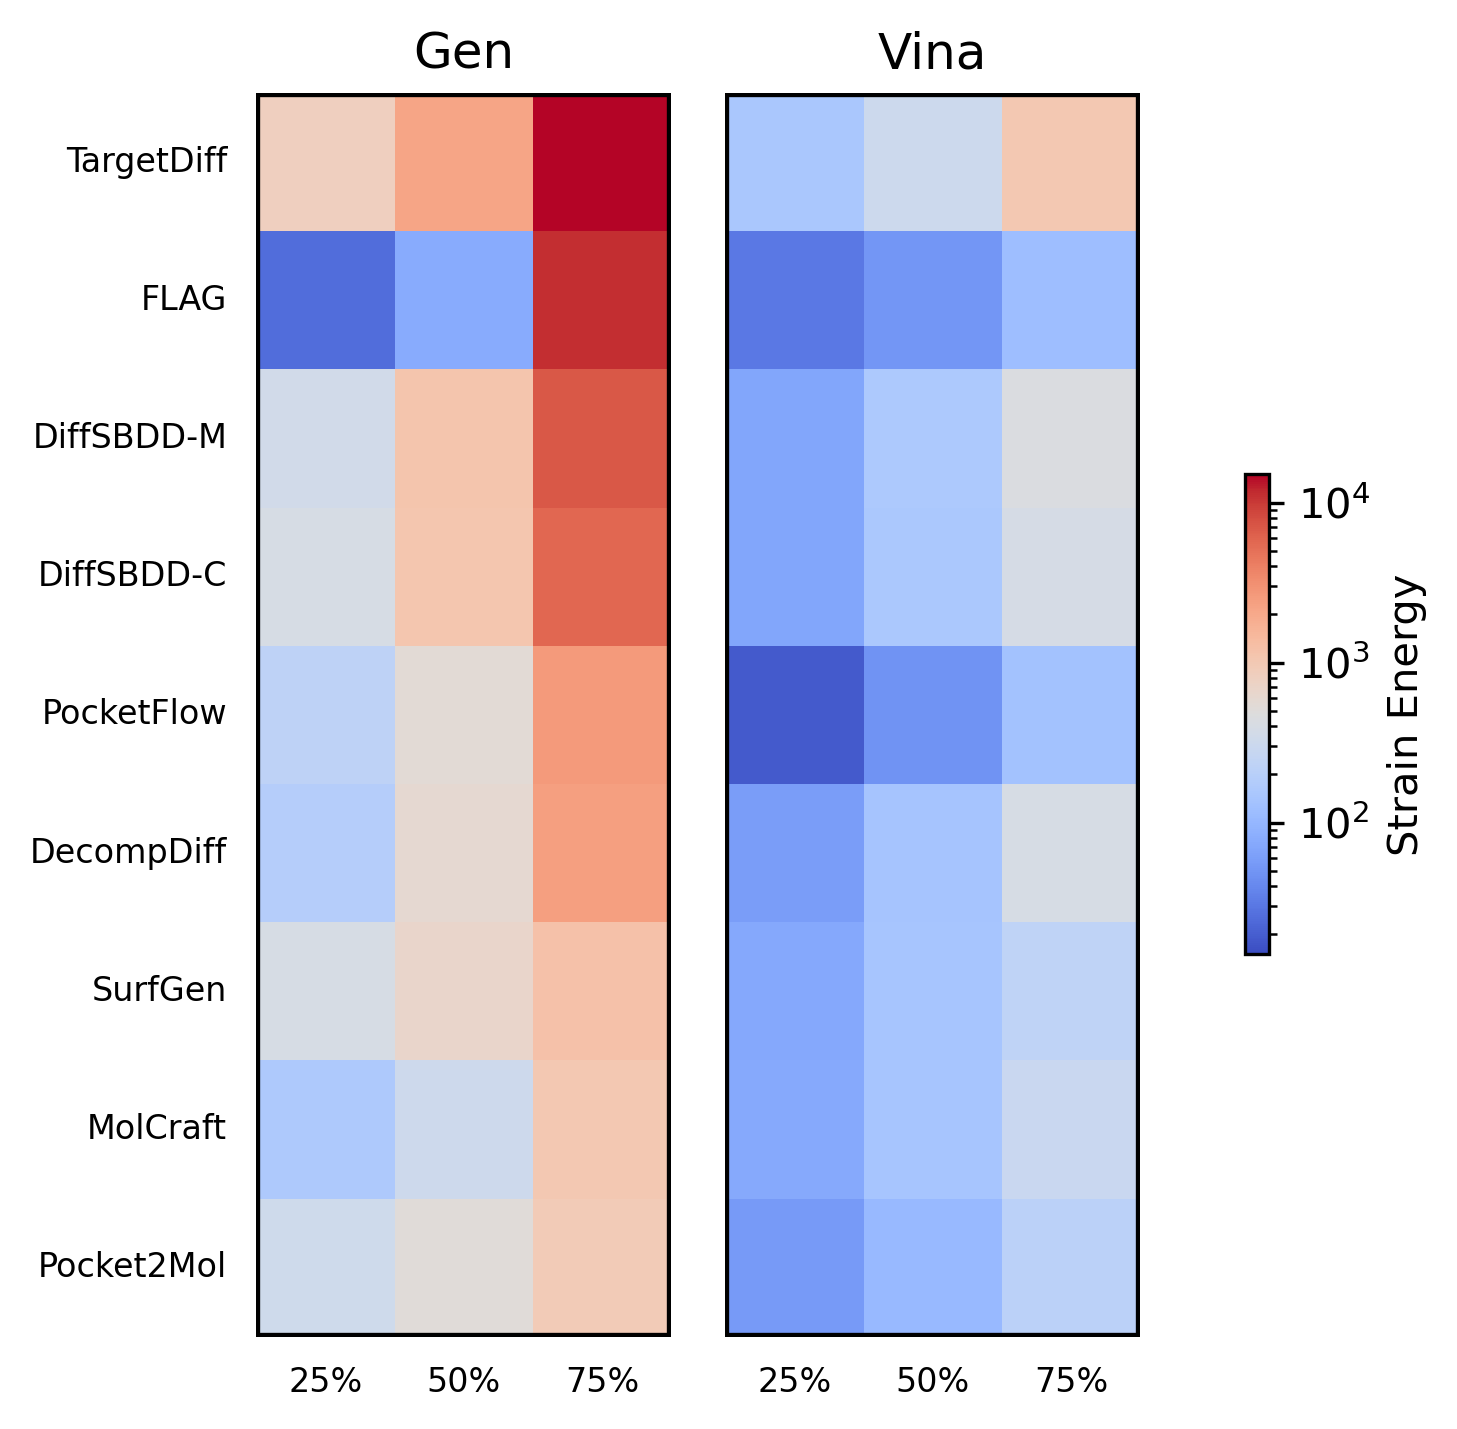

/tmp/ipykernel_4075676/3061628019.py:238: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


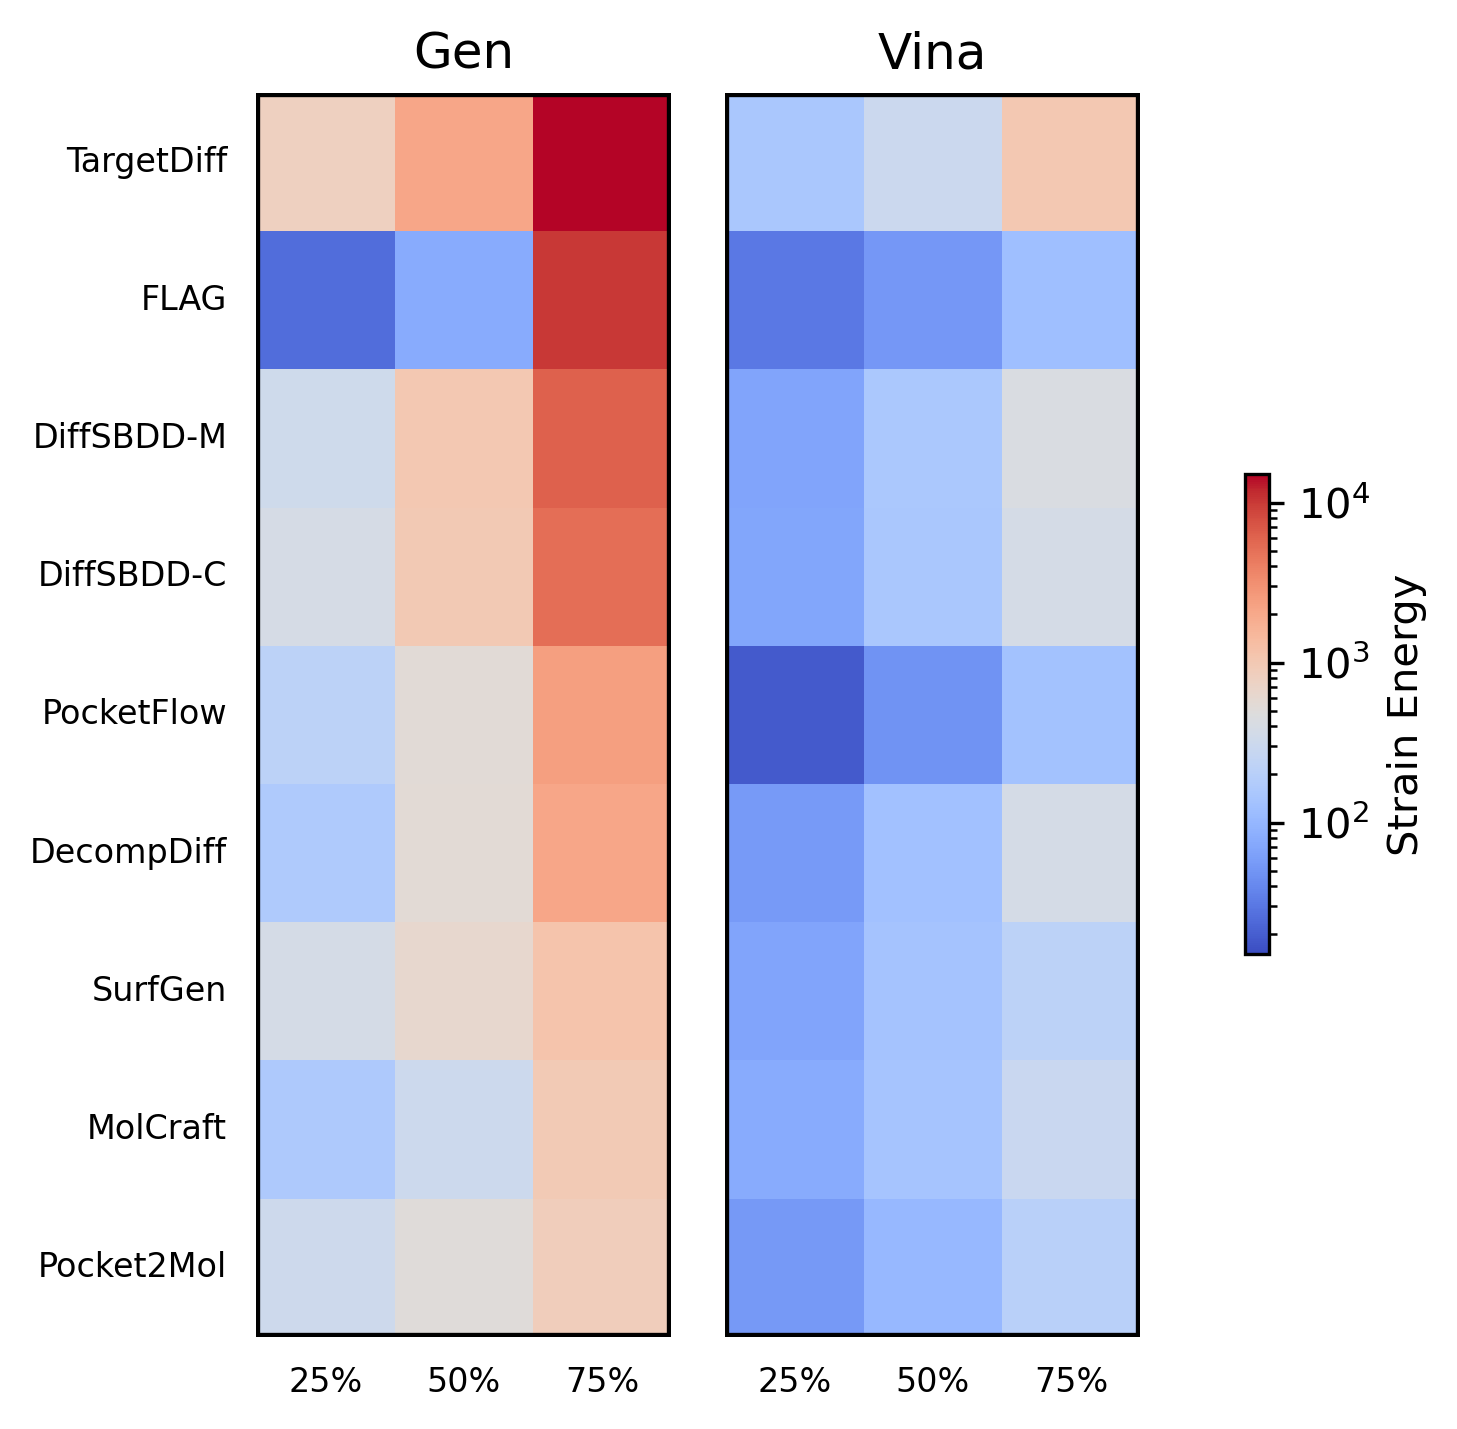

/tmp/ipykernel_4075676/3061628019.py:238: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


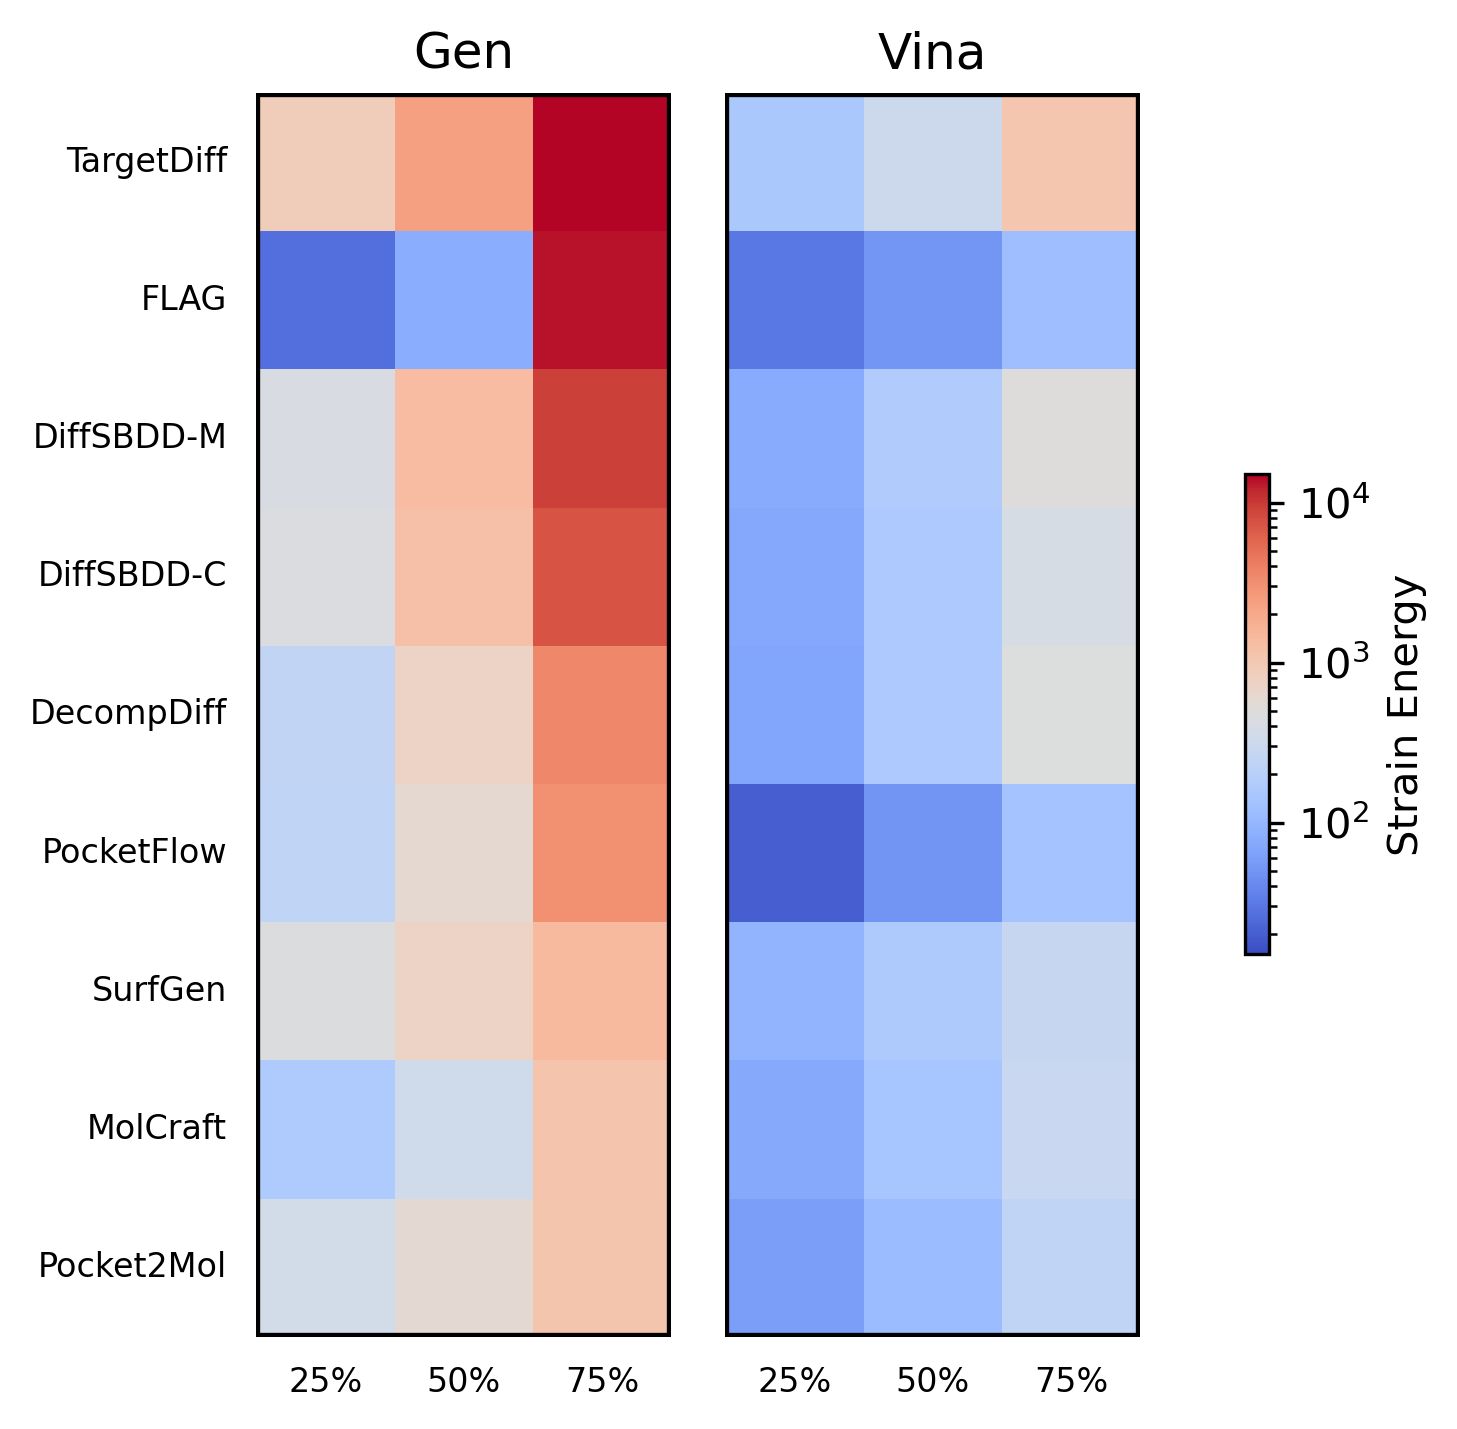

In [ ]:
save_dir = "../final_plot/output"
os.makedirs(save_dir, exist_ok=True)

# All proteins
result_df_all = prepare_heatmap_data(df_mean_all)
plot_strain_heatmap(result_df_all, os.path.join(save_dir, "06-strain_heatmap_denovo_all.svg"))

# Seen proteins
result_df_seen = prepare_heatmap_data(df_mean_seen)
plot_strain_heatmap(result_df_seen, os.path.join(save_dir, "06-strain_heatmap_denovo_seen.svg"))

# Unseen proteins
result_df_unseen = prepare_heatmap_data(df_mean_unseen)
plot_strain_heatmap(result_df_unseen, os.path.join(save_dir, "06-strain_heatmap_denovo_unseen.svg"))